In [1]:
from timeit import timeit

import jax
import jax.random as jrandom
import jax.numpy as jnp
from jax import config
# config.update("jax_enable_x64", True)

from diffrax import diffeqsolve, ControlTerm, Euler, MultiTerm, ODETerm, SaveAt, VirtualBrownianTree, Tsit5, \
    VirtualBrownianTree, SEA, ShARK, PIDController, LevyVal, ALIGN
from test.sde_solver_convergence import solver_order, solver_distance, solutions, l2_dist

import diffrax
import math
import matplotlib.pyplot as plt

jnp.set_printoptions(precision=4, suppress=True)

def show_conv_results(hs, errs):
    plt.plot(1/hs, errs)
    plt.yscale("log")
    plt.xscale("log")
    plt.xticks(ticks=1/hs, labels=hs)
    plt.ylabel("RMS error")
    plt.xlabel("step size")
    plt.show()
    slope, intercept = jnp.polyfit(jnp.log(hs), jnp.log(errs), 1)
    print(f"Order of convergence: {slope:.4f}")

def plot_sol(sol, dim=1):
    plt.plot(sol.ts, sol.ys[:,:dim], label="x")
    plt.plot(sol.ts, sol.ys[:,dim:], label="v")
    plt.legend()
    plt.show()

num_samples = 1000
keys = jrandom.split(jrandom.PRNGKey(2), num=num_samples)

## Harmonic Oscillator SDE

Given by 
\begin{align*}
    d \mathbf{x}_t &= \mathbf{v}_t \, dt \\
    d \mathbf{v}_t &= - \gamma \, \mathbf{v}_t \, dt - u \, \mathbf{x}_t \, dt + \sqrt{2 \gamma u} \, d W_t
\end{align*}
where $\mathbf{x}_t, \mathbf{v}_t, W_t \in \mathbb{R}^2$.

In [2]:
def drift(t, y, args):
    gamma, u, grad_f = args
    x, v = y[:2], y[2:]
    d_x = v
    d_v = -gamma * v - u * grad_f(x)
    d_y = jnp.array([d_x, d_v], dtype=y.dtype).flatten()
    return d_y


def diffusion(t, y, args):
    gamma, u, _ = args
    d_v = jnp.sqrt(2 * gamma * u) * jnp.ones((2,), dtype=y.dtype)
    d_y = jnp.concatenate((jnp.zeros((2, 2), dtype=y.dtype), jnp.diag(d_v)), axis=0)
    return d_y

args = (jnp.float32(0.3), jnp.float32(5.0), lambda x: x)
y0 = jnp.array([0, 0, 0, 0], dtype=jnp.float32)
t0, t1 = 0.3, 15
w_dim_hosc = 2
harmonic_osc = (drift, diffusion, args, y0, t0, t1, w_dim_hosc)

In [3]:
hs, ALIGN_errs = solver_order(keys, harmonic_osc, ALIGN(), ALIGN(), 0.005, hs_num=6)

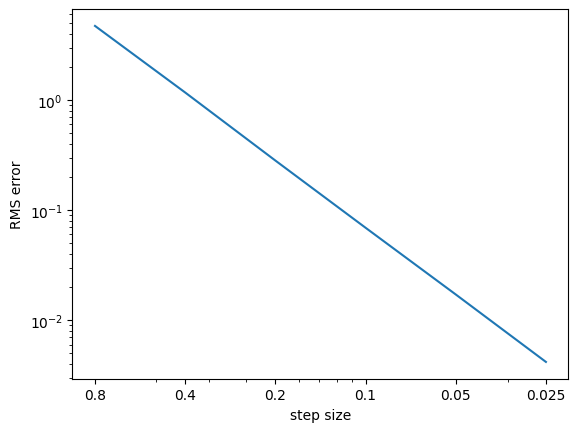

Order of convergence: 2.0295


In [4]:
show_conv_results(hs, ALIGN_errs)

In [5]:
print(f"Each time the step size halves, the error falls by a factor of: {ALIGN_errs[1:]/ALIGN_errs[:-1]}")

Each time the step size halves, the error falls by a factor of: [4.1026 4.0389 4.0796 4.1516 4.0286]


Now compare the RMS error of different methods when using $dt = 0.1$, against a "correct solution" created vie fine-grained Euler.

In [3]:

correct_sol = solutions(keys, harmonic_osc, dt0=0.005, solver=Euler())
euler_sol = solutions(keys, harmonic_osc, dt0=0.1, solver=Euler())
sea_sol = solutions(keys, harmonic_osc, dt0=0.1, solver=SEA())
shark_sol = solutions(keys, harmonic_osc, dt0=0.1, solver=ShARK())
align_sol = solutions(keys, harmonic_osc, dt0=0.1, solver=ALIGN())
align_pid_sol = solutions(keys, harmonic_osc, dt0=0.1, solver=ALIGN(), stepsize_controller=PIDController(rtol=0.001, atol=0.0003))

In [4]:
print(f"Euler       {l2_dist(correct_sol,euler_sol):.4f}")
print(f"SEA         {l2_dist(correct_sol,sea_sol):.4f}")
print(f"ShARK       {l2_dist(correct_sol,shark_sol):.4f}")
print(f"ALIGN       {l2_dist(correct_sol,align_sol):.4f}")
print(f"ALIGN_PID   {l2_dist(correct_sol,align_pid_sol):.4f}")

Euler       15.8456
SEA         15.7760
ShARK       0.3118
ALIGN       0.0691
ALIGN_PID   0.1905


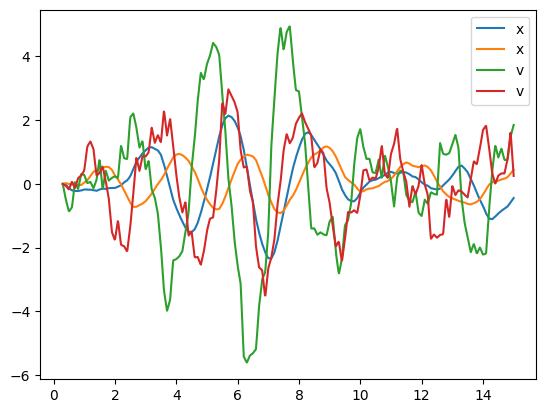

In [8]:
bm = VirtualBrownianTree(t0, t1, tol=2**-9, shape=(w_dim_hosc,), key=jrandom.PRNGKey(2), compute_stla=True)
terms = MultiTerm(ODETerm(drift), ControlTerm(diffusion, bm))
solALIGN = diffeqsolve(terms, ALIGN(), t0, t1, dt0=0.1, y0=y0, args=args, saveat=SaveAt(ts=jnp.linspace(t0, t1, 1000)))
plot_sol(solALIGN, dim=2)

## Timing for Euler, ALIGN, and ShARK

In [24]:
# EULER 1000 samples
jax.block_until_ready(solutions(keys, harmonic_osc, dt0=0.1, solver=Euler()))
%timeit jax.block_until_ready(solutions(keys, harmonic_osc, dt0=0.1, solver=Euler()))

204 ms ± 5.13 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [25]:
# ShARK 1000 samples
jax.block_until_ready(solutions(keys, harmonic_osc, dt0=0.1, solver=ShARK()))
%timeit jax.block_until_ready(solutions(keys, harmonic_osc, dt0=0.1, solver=ShARK()))

208 ms ± 18.7 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [26]:
# ALIGN 1000 samples
jax.block_until_ready(solutions(keys, harmonic_osc, dt0=0.1, solver=ALIGN()))
%timeit jax.block_until_ready(solutions(keys, harmonic_osc, dt0=0.1, solver=ALIGN()))

195 ms ± 3.12 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [27]:
# ALIGN 10x more steps, 1000 samples
jax.block_until_ready(solutions(keys, harmonic_osc, dt0=0.01, solver=ALIGN()))
%timeit jax.block_until_ready(solutions(keys, harmonic_osc, dt0=0.01, solver=ALIGN()))

2 s ± 75.7 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [28]:
# ALIGN 10 samples
keys_short = jrandom.split(jrandom.PRNGKey(2), num=10)
jax.block_until_ready(solutions(keys_short, harmonic_osc, dt0=0.1, solver=ALIGN()))
%timeit jax.block_until_ready(solutions(keys_short, harmonic_osc, dt0=0.1, solver=ALIGN()))

199 ms ± 17.3 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [29]:
# ALIGN 100,000 samples
keys_long = jrandom.split(jrandom.PRNGKey(2), num=100000)
jax.block_until_ready(solutions(keys_long, harmonic_osc, dt0=0.1, solver=ALIGN()))
%timeit jax.block_until_ready(solutions(keys_long, harmonic_osc, dt0=0.1, solver=ALIGN()))

3.11 s ± 3.07 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


## Bistable Quartic potential

Given by 
\begin{align*}
    d x_t &= v_t \, dt \\
    d v_t &= - \gamma \, v_t \, dt - u \, \nabla f( x_t ) \, dt + \sqrt{2 \gamma u} \, d W_t
\end{align*}
where $x_t, v_t, W_t \in \mathbb{R}$ and $f(x) = (x-1)^2 (x+1)^2$.

In [14]:
def drift_bqp(t, y, args):
    gamma, u, grad_f = args
    x, v = y[:2], y[2:]
    d_x = v
    d_v = -gamma * v - u * grad_f(x)
    d_y = jnp.array([d_x, d_v], dtype=y.dtype).flatten()
    return d_y


def diffusion_bqp(t, y, args):
    gamma, u, _ = args
    d_v = jnp.sqrt(2 * gamma * u)
    d_y = jnp.array([0, d_v], dtype=y.dtype)
    return d_y

grad_f = lambda x: 4 * x *(jnp.square(x) - 1)

args_bqp = (jnp.float32(0.8), jnp.float32(0.2), grad_f)
y0 = jnp.array([0, 0], dtype=jnp.float32)
t0, t1 = 0.3, 15
w_dim_bqp = 1
bqp = (drift_bqp, diffusion_bqp, args_bqp, y0, t0, t1, w_dim_bqp)

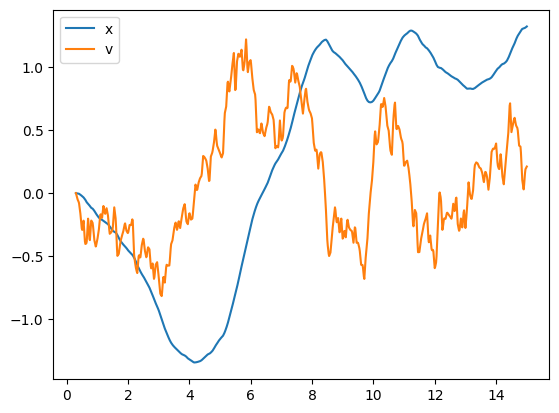

In [15]:
bm = VirtualBrownianTree(t0, t1, tol=2**-9, shape=(), key=jrandom.PRNGKey(4), compute_stla=True)
terms = MultiTerm(ODETerm(drift_bqp), ControlTerm(diffusion_bqp, bm))
solALIGN = diffeqsolve(terms, ALIGN(), t0, t1, dt0=0.05, y0=y0, args=args_bqp, saveat=SaveAt(ts=jnp.linspace(t0, t1, 1000)))
plot_sol(solALIGN, dim=1)

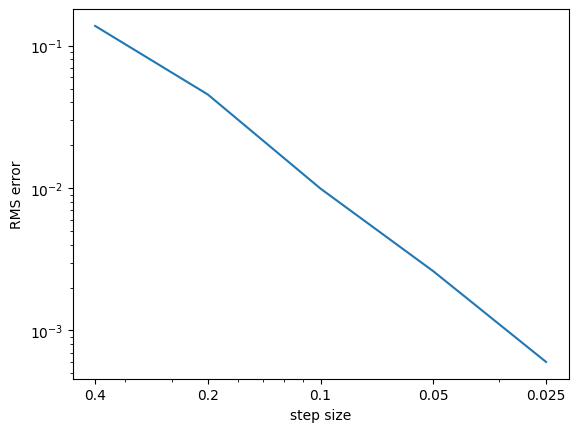

Order of convergence: 1.9801


In [16]:
hs, ALIGN_errs_bqp = solver_order(keys, bqp, ALIGN(), ALIGN(), 0.005)
show_conv_results(hs, ALIGN_errs_bqp)

In [17]:
print(hs)
print(ALIGN_errs_bqp)

[0.025 0.05  0.1   0.2   0.4  ]
[0.0006 0.0026 0.0099 0.0454 0.1376]


## Adaptive stepping with a PID controller

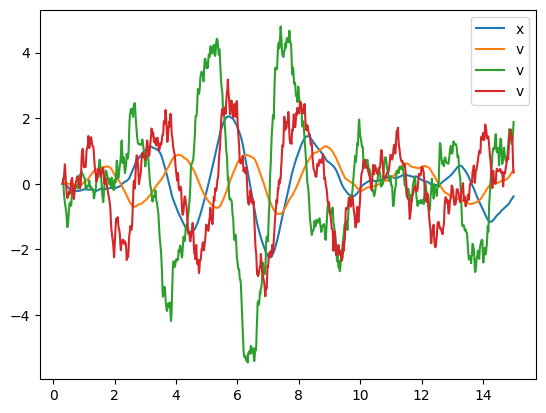

In [6]:
bm = VirtualBrownianTree(t0, t1, tol=2**-9, shape=(w_dim_hosc,), key=jrandom.PRNGKey(2), compute_stla=True)
terms = MultiTerm(ODETerm(drift), ControlTerm(diffusion, bm))
stepsize_controller = PIDController(rtol=0.003, atol=0.001)
solALIGN_PID = diffeqsolve(terms, ALIGN(), t0, t1, dt0=1.0, y0=y0, args=args, saveat=SaveAt(ts=jnp.linspace(t0, t1, 1000)), stepsize_controller=stepsize_controller)
plot_sol(solALIGN_PID)